# Fase 1 - Modelo Predictivo (Titanic) - Google Colab

## Objetivo
El objetivo de este notebook es desarrollar y entrenar un modelo de Machine Learning capaz de predecir si un pasajero sobrevivió o no al hundimiento del Titanic, utilizando datos históricos proporcionados por Kaggle.

El proyecto se basa en la competición:

**Titanic - Machine Learning from Disaster (Kaggle)**

El resultado final de este proceso será:
- Un modelo entrenado capaz de generar predicciones.
- Un archivo de salida `submission.csv` con las predicciones para el conjunto de prueba.
- Un archivo `.pkl` que almacena el modelo entrenado para futuras fases del proyecto.

---

## Entorno de ejecución (Google Colab)
Este notebook fue diseñado para ejecutarse en **Google Colab**, lo cual permite:
- Ejecutar el entrenamiento sin necesidad de instalaciones adicionales.
- Utilizar librerías ya disponibles en el entorno.
- Generar automáticamente los archivos requeridos para la entrega.

Para ejecutar el notebook correctamente, se recomienda correr las celdas en orden secuencial.

## PASO 1: # Creación de la estructura del proyecto en Google Colab

En esta sección se configura el entorno de trabajo dentro de Google Colab.  
Debido a que Colab utiliza un almacenamiento temporal en la ruta `/content`, se crea un directorio principal llamado `titanic_project` para organizar adecuadamente el proyecto.

Dentro de este directorio se generan tres subcarpetas principales:

- `data/`: almacena los archivos originales del dataset descargado desde Kaggle (train.csv, test.csv, etc.).
- `models/`: almacena el modelo entrenado guardado en disco (por ejemplo en formato `.pkl`).
- `outputs/`: almacena los archivos de salida generados por el modelo, como el archivo `submission.csv`.

Esta estructura facilita el manejo de rutas y permite que el proyecto esté listo para ser reutilizado en fases posteriores, como Docker y API REST.

In [2]:
import os
import subprocess

# Crear directorio de trabajo
work_dir = '/content/titanic_project'
os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)

# Crear subdirectorios
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print(f"✅ Directorio de trabajo: {os.getcwd()}")
print("✅ Carpetas creadas: data/, models/, outputs/")

✅ Directorio de trabajo: /content/titanic_project
✅ Carpetas creadas: data/, models/, outputs/


## PASO 2: Carga manual de los archivos del dataset en Google Colab

En este paso se cargan manualmente los archivos CSV del dataset Titanic desde el computador local hacia el entorno de Google Colab.

Debido a que Google Colab no conserva archivos de manera permanente entre sesiones (el almacenamiento se reinicia cuando se cierra o reinicia el entorno), es necesario subir nuevamente los archivos de datos cada vez que se ejecuta el notebook desde cero.

La celda utiliza la función `files.upload()` para seleccionar y cargar archivos desde el equipo del usuario. Posteriormente, los archivos cargados se mueven automáticamente a la carpeta `data/`, garantizando que el notebook pueda acceder a ellos mediante rutas organizadas como:

- `data/train.csv`
- `data/test.csv`

Esto asegura que el proyecto mantenga una estructura clara y que las siguientes etapas del proceso puedan ejecutarse sin errores de ubicación de archivos.

In [30]:
# Subir archivos manualmente:
from google.colab import files

print("Selecciona los archivos CSV en tu computadora:")
print("Selecciona train.csv y test.csv")
print("")

uploaded = files.upload()
for fn in uploaded.keys():
  # Mover a carpeta data
  import shutil
  shutil.move(fn, f'data/{fn}')
  print(f'✅ {fn} subido')


print("")


Selecciona los archivos CSV en tu computadora:
Selecciona train.csv y test.csv



Saving test.csv to test.csv
Saving train.csv to train.csv
✅ test.csv subido
✅ train.csv subido



## PASO 3: Importar Librerías
En esta sección se importan todas las librerías que serán utilizadas durante el desarrollo del modelo predictivo.

Se incluyen librerías para:

- **Manipulación de datos**: `pandas` y `numpy`, utilizadas para cargar, transformar y analizar los datasets.
- **Control de advertencias**: se desactivan mensajes no críticos para mantener una salida más limpia en el notebook.
- **Visualización**: `matplotlib` y `seaborn`, empleadas para explorar el comportamiento de variables y comprender la distribución de los datos.
- **Preprocesamiento y modelado**: herramientas de `scikit-learn` para dividir el dataset, imputar valores faltantes, transformar variables categóricas, escalar datos y construir un pipeline de entrenamiento.
- **Métricas de evaluación**: funciones para medir el rendimiento del modelo, incluyendo accuracy, matriz de confusión y métricas basadas en curvas ROC.
- **Persistencia del modelo**: `joblib`, utilizada para guardar el modelo entrenado en disco y reutilizarlo en fases posteriores del proyecto (Docker y API REST).


In [31]:
# Datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

# Persistencia
import joblib

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## Paso 4. Carga de los datos de entrenamiento y prueba

En este paso se cargan los archivos principales del dataset Titanic desde el entorno de Google Colab.

Se cargan dos archivos:

- `train.csv`: conjunto de entrenamiento, que contiene las variables predictoras y la variable objetivo `Survived`.
- `test.csv`: conjunto de prueba, que contiene únicamente las variables predictoras y se utiliza para generar predicciones finales.

Después de cargar los datos, se imprime la dimensión de ambos conjuntos (`shape`) para verificar que la carga se realizó correctamente y que el número de columnas coincide con lo esperado.

Finalmente, se muestran las primeras filas del dataset de entrenamiento con el objetivo de inspeccionar rápidamente la estructura y confirmar que los datos están disponibles para el análisis.

In [32]:
# Cargar datos
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

print("✅ Datos cargados correctamente")
print(f"   Train: {train_df.shape}")
print(f"   Test: {test_df.shape}")
print(f"\nPrimeras filas:")
train_df.head()

✅ Datos cargados correctamente
   Train: (891, 12)
   Test: (418, 11)

Primeras filas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Paso 5. Exploración inicial del dataset

En esta sección se realiza una exploración básica del conjunto de datos de entrenamiento con el fin de comprender su estructura y calidad.

Se ejecutan tres análisis principales:

- **Información general del dataset (`info`)**: permite identificar el número de registros, el tipo de datos de cada columna (numérico o categórico) y la cantidad de valores no nulos.
- **Detección de valores faltantes (`isnull().sum()`)**: muestra cuántos datos faltan por variable, lo cual es fundamental para definir estrategias de imputación en el preprocesamiento.
- **Estadísticas descriptivas (`describe`)**: calcula medidas como media, desviación estándar, valores mínimos y máximos, y percentiles para las variables numéricas.

Este paso es importante porque permite tomar decisiones fundamentadas sobre limpieza de datos, selección de variables y preparación del modelo.

In [11]:
print("="*60)
print("INFORMACIÓN DEL DATASET")
print("="*60)
train_df.info()

print("\n" + "="*60)
print("VALORES FALTANTES")
print("="*60)
print(train_df.isnull().sum())

print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)
print(train_df.describe())

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

VALORES FALTANTES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin      

## Paso 6. Análisis exploratorio de la variable objetivo (Survived)

En esta sección se analiza la variable objetivo `Survived`, que representa si un pasajero sobrevivió o no al hundimiento del Titanic:

- 0 = No sobrevivió  
- 1 = Sobrevivió  

Primero se calcula la distribución de sobrevivientes y no sobrevivientes, así como el porcentaje total de supervivencia en el dataset. Esto permite verificar si el conjunto de datos está balanceado o si existe un desbalance de clases, lo cual puede influir en el desempeño del modelo.

Posteriormente, se generan visualizaciones para explorar relaciones relevantes entre la supervivencia y otras variables importantes:

- **Distribución general de supervivencia**
- **Supervivencia según género (Sex)**
- **Supervivencia según clase del pasajero (Pclass)**

Este análisis exploratorio permite identificar patrones iniciales y variables potencialmente relevantes para el entrenamiento del modelo predictivo.


Distribución de Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Porcentaje de sobrevivientes: 38.38%


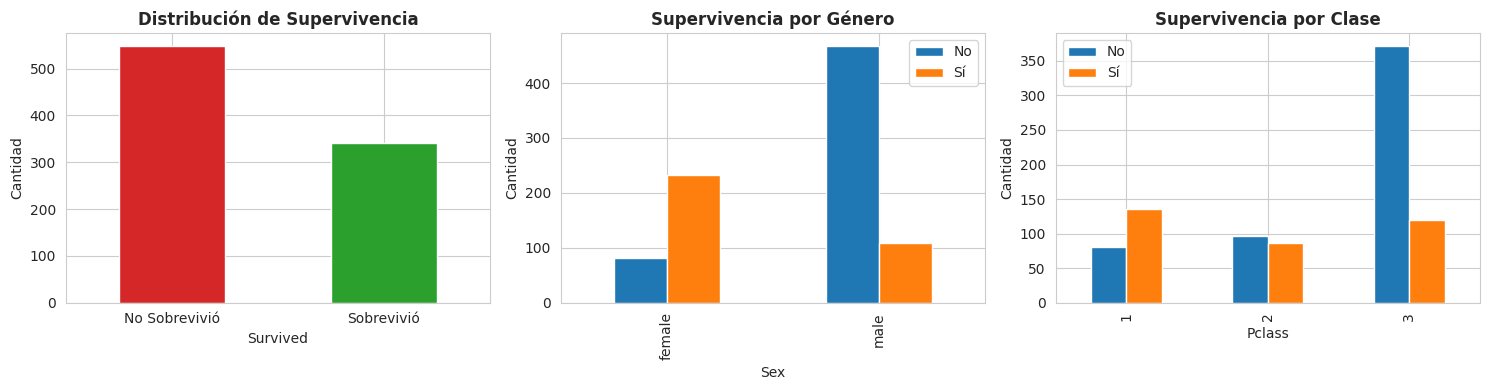

✅ Gráficos generados


In [12]:
# Análisis de supervivencia
print("\nDistribución de Survived:")
print(train_df['Survived'].value_counts())
print(f"\nPorcentaje de sobrevivientes: {(train_df['Survived'].sum() / len(train_df)) * 100:.2f}%")

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train_df['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#d62728', '#2ca02c'])
axes[0].set_title('Distribución de Supervivencia', fontweight='bold')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['No Sobrevivió', 'Sobrevivió'], rotation=0)

pd.crosstab(train_df['Sex'], train_df['Survived']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Supervivencia por Género', fontweight='bold')
axes[1].set_ylabel('Cantidad')
axes[1].legend(['No', 'Sí'])

pd.crosstab(train_df['Pclass'], train_df['Survived']).plot(kind='bar', ax=axes[2])
axes[2].set_title('Supervivencia por Clase', fontweight='bold')
axes[2].set_ylabel('Cantidad')
axes[2].legend(['No', 'Sí'])

plt.tight_layout()
plt.show()

print("✅ Gráficos generados")

## Paso 7. Selección de variables predictoras (features) y variable objetivo

En esta sección se seleccionan las variables que serán utilizadas como entrada del modelo predictivo.

Se separan las variables en dos grupos:

- **Variables categóricas** (`categorical_features`): contienen valores de tipo texto o categorías, por ejemplo:
  - `Sex`
  - `Embarked`

- **Variables numéricas** (`numeric_features`): contienen valores cuantitativos, por ejemplo:
  - `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`

Posteriormente, se construye el conjunto de variables predictoras `X`, que contiene únicamente las columnas seleccionadas, y la variable objetivo `y`, que corresponde a la columna `Survived`.

Este paso es fundamental porque define la información que el modelo utilizará para aprender patrones y generar predicciones.

In [13]:
# Definir features
categorical_features = ["Sex", "Embarked"]
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

# Separar X e y
X = train_df[categorical_features + numeric_features].copy()
y = train_df["Survived"].copy()

print(f"Features seleccionadas: {categorical_features + numeric_features}")
print(f"Dimensiones X: {X.shape}")
print(f"Dimensiones y: {y.shape}")

Features seleccionadas: ['Sex', 'Embarked', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Dimensiones X: (891, 7)
Dimensiones y: (891,)


## Paso 8. División del dataset en entrenamiento y validación

En esta sección se divide el conjunto de datos en dos partes:

- **Conjunto de entrenamiento (`X_train`, `y_train`)**: utilizado para entrenar el modelo.
- **Conjunto de validación (`X_val`, `y_val`)**: utilizado para evaluar el desempeño del modelo con datos no vistos durante el entrenamiento.

Se utiliza una proporción de:
- 80% para entrenamiento
- 20% para validación (`test_size=0.2`)

Además, se emplea el parámetro `stratify=y` para asegurar que la proporción de sobrevivientes y no sobrevivientes sea similar en ambos conjuntos, evitando sesgos por desbalance de clases.

Finalmente, se imprimen las dimensiones de cada conjunto para confirmar que la división se realizó correctamente.

In [14]:
# División de datos
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")

X_train: (712, 7)
X_val: (179, 7)


## Paso 9. Definición del preprocesamiento de datos (Pipeline)

En esta sección se define el proceso de preparación de datos antes de entrenar el modelo.  
El preprocesamiento es necesario porque el dataset contiene valores faltantes y variables de distintos tipos (numéricas y categóricas).

Se construyen dos pipelines independientes:

### Preprocesamiento para variables numéricas
- **Imputación de valores faltantes** usando la mediana (`median`), lo cual es adecuado cuando existen valores extremos.
- **Escalamiento** mediante `StandardScaler`, que normaliza los valores numéricos para mejorar el desempeño del modelo.

### Preprocesamiento para variables categóricas
- **Imputación de valores faltantes** usando el valor más frecuente (`most_frequent`).
- **Codificación One-Hot** mediante `OneHotEncoder`, que convierte las categorías en variables numéricas binarias para que el modelo pueda interpretarlas.

Finalmente, se utiliza `ColumnTransformer` para aplicar automáticamente el preprocesamiento adecuado a cada conjunto de variables (numéricas y categóricas), generando un dataset listo para el entrenamiento del modelo.

In [15]:
# Crear preprocesadores
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("✅ Preprocesadores definidos")

✅ Preprocesadores definidos


## Paso 10. Construcción del pipeline completo y entrenamiento del modelo

En esta sección se construye el pipeline final que integra todo el flujo de procesamiento y entrenamiento en un solo modelo reproducible.

El pipeline incluye dos etapas principales:

1. **Preprocesamiento (`preprocessor`)**: aplica automáticamente la imputación de valores faltantes, el escalamiento de variables numéricas y la codificación de variables categóricas.
2. **Modelo predictivo (`RandomForestClassifier`)**: se utiliza un algoritmo de tipo Random Forest, el cual combina múltiples árboles de decisión para mejorar la capacidad predictiva y reducir el sobreajuste.

El modelo se entrena utilizando los datos del conjunto de entrenamiento (`X_train`, `y_train`).  
Además, se configura `n_jobs=-1` para aprovechar todos los núcleos disponibles del procesador y acelerar el entrenamiento.

Este paso es fundamental, ya que permite obtener un modelo capaz de aprender patrones en los datos y posteriormente generar predicciones sobre nuevos pasajeros.

In [16]:
# Crear pipeline
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Entrenando modelo...")
clf.fit(X_train, y_train)
print("✅ Modelo entrenado")

Entrenando modelo...
✅ Modelo entrenado


## Paso 11. Evaluación del modelo mediante validación cruzada (Cross-Validation)

En esta sección se evalúa el desempeño del modelo utilizando **validación cruzada estratificada** (Stratified K-Fold).

La validación cruzada consiste en dividir el conjunto de entrenamiento en varios subconjuntos (folds) y entrenar el modelo múltiples veces, utilizando en cada iteración una parte diferente como validación. Esto permite obtener una evaluación más confiable del rendimiento del modelo, reduciendo la dependencia de una única partición de datos.

Se utiliza `StratifiedKFold` con 5 divisiones (`n_splits=5`), lo cual garantiza que en cada fold se mantenga la misma proporción de clases (sobrevivientes y no sobrevivientes) que en el dataset original.

Finalmente, se calcula el accuracy para cada fold y se reporta:
- el accuracy individual de cada partición,
- el accuracy promedio,
- y la desviación estándar como medida de estabilidad del modelo.

Este procedimiento ayuda a estimar qué tan bien generaliza el modelo a datos nuevos.

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')

print("\n" + "="*60)
print("CROSS-VALIDATION SCORES (5-Fold)")
print("="*60)
print(f"Accuracy en cada fold: {cv_scores}")
print(f"Accuracy promedio: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CROSS-VALIDATION SCORES (5-Fold)
Accuracy en cada fold: [0.81818182 0.7972028  0.82394366 0.78169014 0.80985915]
Accuracy promedio: 0.8062 (+/- 0.0152)


## Paso 12. Evaluación del modelo con el conjunto de validación

En esta sección se evalúa el modelo utilizando el conjunto de validación (`X_val`, `y_val`), el cual contiene datos que no fueron utilizados durante el entrenamiento.

Primero se generan:

- **Predicciones finales (`predict`)**: devuelve la clase estimada (0 o 1).
- **Probabilidades (`predict_proba`)**: devuelve la probabilidad estimada de pertenecer a la clase positiva (sobrevivir).

Posteriormente se calculan métricas clave de desempeño:

- **Accuracy**: proporción de predicciones correctas respecto al total.
- **AUC ROC**: mide la capacidad del modelo para distinguir entre sobrevivientes y no sobrevivientes utilizando probabilidades, siendo útil incluso cuando existe desbalance en las clases.

Finalmente, se imprime un **classification report**, que incluye:
- precisión (precision),
- sensibilidad o recall,
- F1-score,
- soporte (cantidad de observaciones por clase).

Este análisis permite evaluar de manera más completa el rendimiento del modelo antes de generar las predicciones finales para Kaggle.

In [18]:
# Predicciones
y_val_pred = clf.predict(X_val)
y_val_pred_proba = clf.predict_proba(X_val)[:, 1]

# Métricas
accuracy = accuracy_score(y_val, y_val_pred)
auc_score = roc_auc_score(y_val, y_val_pred_proba)

print("\n" + "="*60)
print("EVALUACIÓN EN VALIDACIÓN")
print("="*60)
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC ROC: {auc_score:.4f}")
print(f"\n{classification_report(y_val, y_val_pred, target_names=['No Sobrevivió', 'Sobrevivió'])}")


EVALUACIÓN EN VALIDACIÓN
Accuracy: 0.8156
AUC ROC: 0.8287

               precision    recall  f1-score   support

No Sobrevivió       0.82      0.89      0.86       110
   Sobrevivió       0.80      0.70      0.74        69

     accuracy                           0.82       179
    macro avg       0.81      0.79      0.80       179
 weighted avg       0.81      0.82      0.81       179



## Paso 13. Visualización del desempeño del modelo (Matriz de Confusión y Curva ROC)

En esta sección se generan visualizaciones que permiten interpretar el rendimiento del modelo de forma más intuitiva.

### Matriz de Confusión
Se calcula la **matriz de confusión**, la cual muestra cuántos casos fueron clasificados correctamente e incorrectamente en cada clase:

- Verdaderos negativos (TN): predijo "No sobrevivió" y era correcto.
- Verdaderos positivos (TP): predijo "Sobrevivió" y era correcto.
- Falsos positivos (FP): predijo "Sobrevivió" cuando en realidad no sobrevivió.
- Falsos negativos (FN): predijo "No sobrevivió" cuando en realidad sí sobrevivió.

Esta matriz permite identificar qué tipo de errores comete el modelo con mayor frecuencia.

### Curva ROC (Receiver Operating Characteristic)
Se construye la curva ROC utilizando las probabilidades predichas por el modelo.  
La curva ROC representa el comportamiento del clasificador comparando:

- **True Positive Rate (TPR)**: sensibilidad o recall.
- **False Positive Rate (FPR)**: tasa de falsos positivos.

Además, se calcula el valor **AUC (Área Bajo la Curva)**, el cual resume el desempeño del modelo en un solo valor. Un AUC cercano a 1 indica un modelo con buena capacidad de discriminación.

Estas gráficas complementan las métricas numéricas obtenidas anteriormente y permiten evaluar visualmente la calidad del modelo.

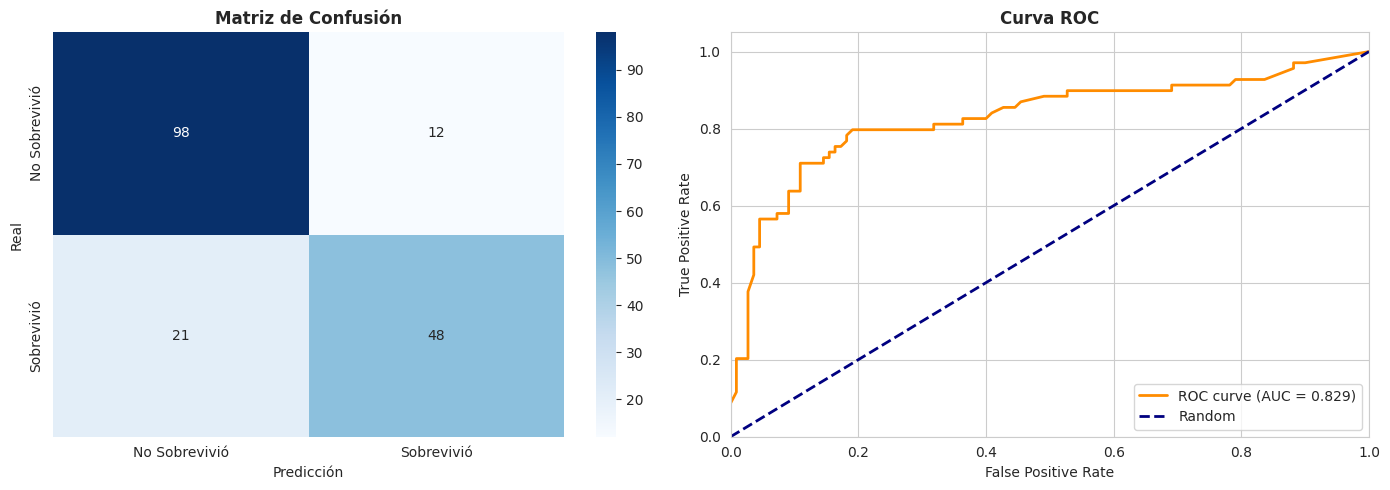

✅ Gráficos de evaluación generados


In [19]:
# Visualizaciones de evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Sobrevivió', 'Sobrevivió'],
            yticklabels=['No Sobrevivió', 'Sobrevivió'])
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

# Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print("✅ Gráficos de evaluación generados")

## Paso 14. Interpretación del modelo: Importancia de variables (Feature Importance)

En esta sección se analiza la **importancia de las variables** utilizadas por el modelo Random Forest.

Los modelos tipo Random Forest permiten estimar qué tan relevante fue cada variable para tomar decisiones durante el entrenamiento. Esta medida se conoce como `feature_importances_` y representa la contribución relativa de cada feature en la reducción de impureza dentro de los árboles del bosque.

Para interpretar correctamente el modelo, se realiza lo siguiente:

1. Se extrae el modelo entrenado desde el pipeline (`clf.named_steps['model']`).
2. Se obtiene el vector de importancias generado por el Random Forest.
3. Se reconstruyen los nombres de las variables finales utilizadas por el modelo:
   - Variables numéricas originales.
   - Variables categóricas transformadas con One-Hot Encoding (por ejemplo, Sex_male, Embarked_S, etc.).
4. Se crea un DataFrame ordenado de mayor a menor importancia.
5. Se genera una visualización tipo barra para identificar gráficamente las variables más influyentes.

Este análisis es útil para comprender el comportamiento del modelo, justificar la selección de variables y detectar cuáles características tienen mayor impacto en la predicción de supervivencia.


Importancia de Features:
      Feature  Importance
4        Fare    0.258759
1         Age    0.243951
6    Sex_male    0.158605
5  Sex_female    0.131465
0      Pclass    0.085362
2       SibSp    0.046857
3       Parch    0.040157
9  Embarked_S    0.014058
7  Embarked_C    0.012751
8  Embarked_Q    0.008034


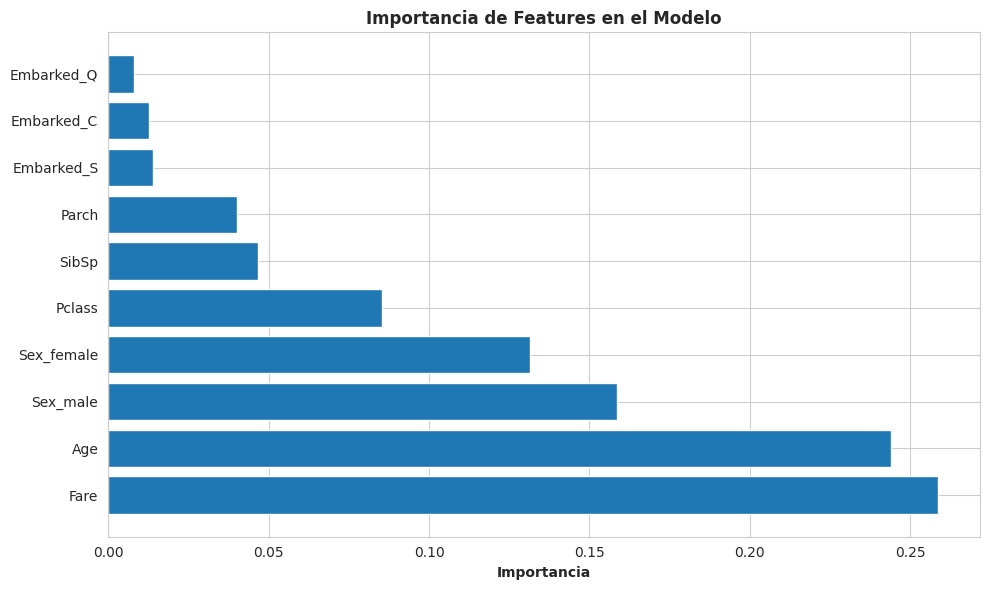

In [20]:
model = clf.named_steps['model']
feature_importance = model.feature_importances_

# Obtener nombres de features
feature_names = []
feature_names.extend(numeric_features)
cat_encoder = clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# DataFrame de importancia
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nImportancia de Features:")
print(importance_df)

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importancia', fontweight='bold')
plt.title('Importancia de Features en el Modelo', fontweight='bold')
plt.tight_layout()
plt.show()

## Paso 15. Entrenamiento final y generación de predicciones para Kaggle

En esta sección se realiza el proceso final antes de construir el archivo de entrega (`submission.csv`).

Primero, el modelo se entrena nuevamente utilizando **todos los datos disponibles** (`X`, `y`).  
Esto se hace porque, una vez evaluado el rendimiento en validación, lo ideal es que el modelo aproveche el 100% del dataset de entrenamiento para maximizar su capacidad predictiva antes de aplicarlo al conjunto de prueba.

Posteriormente, se prepara el dataset de prueba (`test_df`) seleccionando las mismas variables utilizadas en el entrenamiento. Con este conjunto se generan las predicciones finales utilizando el modelo entrenado.

Finalmente, se construye el DataFrame de salida con el formato requerido por Kaggle:

- `PassengerId`: identificador del pasajero.
- `Survived`: predicción del modelo (0 = no sobrevivió, 1 = sobrevivió).

Como verificación, se imprimen las primeras filas del archivo generado y la distribución de clases predichas, con el fin de comprobar que las predicciones tienen sentido y no están sesgadas hacia una sola clase.

In [21]:
# Entrenar con todos los datos
print("Entrenando modelo final con todos los datos...")
clf.fit(X, y)
print("✅ Modelo final entrenado")

Entrenando modelo final con todos los datos...
✅ Modelo final entrenado


In [22]:
# Predicciones en test
X_test = test_df[categorical_features + numeric_features].copy()
test_predictions = clf.predict(X_test)

# Crear submisión
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions
})

print(submission.head(10))
print(f"\nDistribución de predicciones:")
print(submission['Survived'].value_counts())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
5          897         0
6          898         0
7          899         0
8          900         1
9          901         0

Distribución de predicciones:
Survived
0    266
1    152
Name: count, dtype: int64


## PASO 12: Guardar Archivos

In [23]:
# Guardar submisión
submission.to_csv('outputs/submission.csv', index=False)
print("✅ submission.csv guardado")

# Guardar modelo
joblib.dump(clf, 'models/titanic_model.pkl')
print("✅ Modelo guardado en models/titanic_model.pkl")

✅ submission.csv guardado
✅ Modelo guardado en models/titanic_model.pkl


## PASO 13: Descargar Archivos desde Google Drive

In [24]:
from google.colab import files

print("\nArchivos generados en /content/titanic_project/:")
print("\n📊 Resultados:")
print("  - outputs/submission.csv (predicciones)")
print("  - models/titanic_model.pkl (modelo entrenado)")
print("\n💾 Para descargar a tu computadora, usa:")
print("")
print("# Descargar submisión")
print("files.download('outputs/submission.csv')")
print("")
print("# Descargar modelo")
print("files.download('models/titanic_model.pkl')")


Archivos generados en /content/titanic_project/:

📊 Resultados:
  - outputs/submission.csv (predicciones)
  - models/titanic_model.pkl (modelo entrenado)

💾 Para descargar a tu computadora, usa:

# Descargar submisión
files.download('outputs/submission.csv')

# Descargar modelo
files.download('models/titanic_model.pkl')


In [25]:
# Descargar automáticamente
print("Descargando archivos...")
files.download('outputs/submission.csv')
files.download('models/titanic_model.pkl')
print("✅ Archivos descargados a tu computadora")

Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Archivos descargados a tu computadora


## RESUMEN FINAL

In [26]:
print("\n" + "="*60)
print("RESUMEN FINAL DEL PROYECTO")
print("="*60)
print(f"\n✅ Accuracy en validación: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"✅ AUC ROC: {auc_score:.4f}")
print(f"✅ Cross-Validation: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"\n✅ Archivos generados:")
print(f"   - submission.csv (predicciones para Kaggle)")
print(f"   - titanic_model.pkl (modelo entrenado)")
print(f"\n✅ Proyecto completado exitosamente!")
print(f"\n📝 Próximos pasos:")
print(f"   1. Descarga submission.csv")
print(f"   2. Sube a Kaggle para ver tu score")
print(f"   3. Sube todo a GitHub")
print("="*60)


RESUMEN FINAL DEL PROYECTO

✅ Accuracy en validación: 0.8156 (81.56%)
✅ AUC ROC: 0.8287
✅ Cross-Validation: 0.8062 (+/- 0.0152)

✅ Archivos generados:
   - submission.csv (predicciones para Kaggle)
   - titanic_model.pkl (modelo entrenado)

✅ Proyecto completado exitosamente!

📝 Próximos pasos:
   1. Descarga submission.csv
   2. Sube a Kaggle para ver tu score
   3. Sube todo a GitHub
